# E-commerce Sales Data Analysis and Visualization using Python

## Data Import

In [37]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

# Load your file 
df = pd.read_excel("D:\project\ecommerce_raw_data_1000.xlsx")

df.head()

,Order_ID,Customer_ID,City,Product,Category,Price,Quantity,Discount,Order_Date
0,1000.0,10102.0,Chennai,Fruits,Produce,471.0,8.0,10.0,2023-01-01
1,1001.0,10435.0,Chennai,Fruits,Produce,141.0,1.0,0.0,2023-01-02
2,1002.0,10860.0,None,Bread,Produce,288.0,6.0,15.0,2023-01-03
3,1003.0,10270.0,None,Bread,Bakery,371.0,6.0,5.0,2023-01-04
4,1004.0,NaN,None,NaN,Protein,93.0,4.0,NaN,2023-01-05


In [38]:
#first 10 row
df.head(10)

,Order_ID,Customer_ID,City,Product,Category,Price,Quantity,Discount,Order_Date
0,1000.0,10102.0,Chennai,Fruits,Produce,471.0,8.0,10.0,2023-01-01
1,1001.0,10435.0,Chennai,Fruits,Produce,141.0,1.0,0.0,2023-01-02
2,1002.0,10860.0,None,Bread,Produce,288.0,6.0,15.0,2023-01-03
3,1003.0,10270.0,None,Bread,Bakery,371.0,6.0,5.0,2023-01-04
4,1004.0,NaN,None,NaN,Protein,93.0,4.0,NaN,2023-01-05
5,1005.0,10071.0,Delhi,Milk,Packaged,408.0,3.0,10.0,2023-01-06
6,1006.0,10700.0,Bangalore,Fruits,Protein,251.0,3.0,10.0,2023-01-07
7,1007.0,NaN,Chennai,NaN,Protein,125.0,1.0,10.0,2023-01-08
8,1008.0,10614.0,Mumbai,Eggs,Bakery,118.0,3.0,5.0,2023-01-09
9,1009.0,10121.0,Delhi,Bread,Protein,230.0,4.0,15.0,2023-01-10


## Data Cleaning

In [39]:
#Check Missing Values
df.isnull().sum()

Order_ID       100
Customer_ID    100
City             0
Product        100
Category       100
Price          100
Quantity       100
Discount       100
Order_Date     100
dtype: int64

In [40]:
#Handle Missing Values For Numeric Columns

df['Price'].fillna(df['Price'].mean(), inplace= True)
df['Quantity'].fillna(df['Quantity'].median(), inplace= True)
df['Discount'].fillna(0, inplace= True)
df.head(10)

,Order_ID,Customer_ID,City,Product,Category,Price,Quantity,Discount,Order_Date
0,1000.0,10102.0,Chennai,Fruits,Produce,471.0,8.0,10.0,2023-01-01
1,1001.0,10435.0,Chennai,Fruits,Produce,141.0,1.0,0.0,2023-01-02
2,1002.0,10860.0,None,Bread,Produce,288.0,6.0,15.0,2023-01-03
3,1003.0,10270.0,None,Bread,Bakery,371.0,6.0,5.0,2023-01-04
4,1004.0,NaN,None,NaN,Protein,93.0,4.0,0.0,2023-01-05
5,1005.0,10071.0,Delhi,Milk,Packaged,408.0,3.0,10.0,2023-01-06
6,1006.0,10700.0,Bangalore,Fruits,Protein,251.0,3.0,10.0,2023-01-07
7,1007.0,NaN,Chennai,NaN,Protein,125.0,1.0,10.0,2023-01-08
8,1008.0,10614.0,Mumbai,Eggs,Bakery,118.0,3.0,5.0,2023-01-09
9,1009.0,10121.0,Delhi,Bread,Protein,230.0,4.0,15.0,2023-01-10


In [41]:
#For Categorical Columns 
df["Product"].fillna('Unknown', inplace= True)
df["Category"].fillna('Unknown', inplace =True)
df.head(10)

,Order_ID,Customer_ID,City,Product,Category,Price,Quantity,Discount,Order_Date
0,1000.0,10102.0,Chennai,Fruits,Produce,471.0,8.0,10.0,2023-01-01
1,1001.0,10435.0,Chennai,Fruits,Produce,141.0,1.0,0.0,2023-01-02
2,1002.0,10860.0,None,Bread,Produce,288.0,6.0,15.0,2023-01-03
3,1003.0,10270.0,None,Bread,Bakery,371.0,6.0,5.0,2023-01-04
4,1004.0,NaN,None,Unknown,Protein,93.0,4.0,0.0,2023-01-05
5,1005.0,10071.0,Delhi,Milk,Packaged,408.0,3.0,10.0,2023-01-06
6,1006.0,10700.0,Bangalore,Fruits,Protein,251.0,3.0,10.0,2023-01-07
7,1007.0,NaN,Chennai,Unknown,Protein,125.0,1.0,10.0,2023-01-08
8,1008.0,10614.0,Mumbai,Eggs,Bakery,118.0,3.0,5.0,2023-01-09
9,1009.0,10121.0,Delhi,Bread,Protein,230.0,4.0,15.0,2023-01-10


In [42]:
df.isnull().sum()

Order_ID       100
Customer_ID    100
City             0
Product          0
Category         0
Price            0
Quantity         0
Discount         0
Order_Date     100
dtype: int64

In [43]:
#Fix Missing Order_Date
df['Order_Date']= df['Order_Date'].ffill()

#fix missing Customer_ID
df['Customer_ID'] = df['Customer_ID'].fillna(df['Customer_ID'].mode()[0])

In [44]:
#Since Order_ID is a unique identifier, using mean/median is not correct.
#The best simple approach is to fill missing Order_ID with new sequential IDs.

missing_index = df[df['Order_ID'].isnull()].index
start_id = int(df['Order_ID'].max()) + 1
df.loc[missing_index, 'Order_ID'] = range(start_id, start_id + len(missing_index))

In [45]:
df.isnull().sum()

Order_ID       0
Customer_ID    0
City           0
Product        0
Category       0
Price          0
Quantity       0
Discount       0
Order_Date     0
dtype: int64

In [46]:
#check Blank Spaces
# Check unique values in City (you will see spaces issue)
df['City'].unique()

array(['Chennai ', 'None ', 'Delhi ', 'Bangalore ', 'Mumbai ',
       'Hyderabad '], dtype=object)

In [47]:
# Remove spaces from text columns
df['City'] = df['City'].astype(str).str.strip()
df['City'].unique()

array(['Chennai', 'None', 'Delhi', 'Bangalore', 'Mumbai', 'Hyderabad'],
      dtype=object)

In [74]:
# updating in existing excel file
df.to_excel("ecommerce_clean_data.xlsx", index=False)
print("Clean Excel file saved successfully!")
import os
os.getcwd()

Clean Excel file saved successfully!


'C:\\Users\\ASUS'

In [49]:
df.head(10)

,Order_ID,Customer_ID,City,Product,Category,Price,Quantity,Discount,Order_Date
0,1000.0,10102.0,Chennai,Fruits,Produce,471.0,8.0,10.0,2023-01-01
1,1001.0,10435.0,Chennai,Fruits,Produce,141.0,1.0,0.0,2023-01-02
2,1002.0,10860.0,None,Bread,Produce,288.0,6.0,15.0,2023-01-03
3,1003.0,10270.0,None,Bread,Bakery,371.0,6.0,5.0,2023-01-04
4,1004.0,10098.0,None,Unknown,Protein,93.0,4.0,0.0,2023-01-05
5,1005.0,10071.0,Delhi,Milk,Packaged,408.0,3.0,10.0,2023-01-06
6,1006.0,10700.0,Bangalore,Fruits,Protein,251.0,3.0,10.0,2023-01-07
7,1007.0,10098.0,Chennai,Unknown,Protein,125.0,1.0,10.0,2023-01-08
8,1008.0,10614.0,Mumbai,Eggs,Bakery,118.0,3.0,5.0,2023-01-09
9,1009.0,10121.0,Delhi,Bread,Protein,230.0,4.0,15.0,2023-01-10


In [50]:
df.isnull().sum()

Order_ID       0
Customer_ID    0
City           0
Product        0
Category       0
Price          0
Quantity       0
Discount       0
Order_Date     0
dtype: int64

In [51]:
#create total amount column 
df['Total_Amount'] = (df['Price'] * df['Quantity']) - df['Discount']
df.head()

,Order_ID,Customer_ID,City,Product,Category,Price,Quantity,Discount,Order_Date,Total_Amount
0,1000.0,10102.0,Chennai,Fruits,Produce,471.0,8.0,10.0,2023-01-01,3758.0
1,1001.0,10435.0,Chennai,Fruits,Produce,141.0,1.0,0.0,2023-01-02,141.0
2,1002.0,10860.0,None,Bread,Produce,288.0,6.0,15.0,2023-01-03,1713.0
3,1003.0,10270.0,None,Bread,Bakery,371.0,6.0,5.0,2023-01-04,2221.0
4,1004.0,10098.0,None,Unknown,Protein,93.0,4.0,0.0,2023-01-05,372.0


In [52]:
df.describe()

,Order_ID,Customer_ID,Price,Quantity,Discount,Order_Date,Total_Amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,1552.218000,10460.254000,256.398889,5.047000,6.740000,2024-05-14 09:24:28.800000,1289.976417
min,1000.000000,10000.000000,11.000000,1.000000,0.000000,2023-01-01 00:00:00,9.000000
25%,1271.500000,10162.000000,146.000000,3.000000,0.000000,2023-09-07 18:00:00,487.500000
50%,1551.500000,10454.000000,256.398889,5.000000,5.000000,2024-05-14 00:00:00,1104.000000
75%,1834.250000,10728.250000,369.250000,7.000000,10.000000,2025-01-19 06:00:00,1878.250000
max,2099.000000,10998.000000,499.000000,9.000000,15.000000,2025-09-26 00:00:00,4491.000000
std,321.313721,299.179364,134.559124,2.375381,5.679318,NaN,960.371748


In [53]:
df['Price'].max()

499.0

In [54]:
# full row having max value
df[df['Price'] == df['Price'].max()]

,Order_ID,Customer_ID,City,Product,Category,Price,Quantity,Discount,Order_Date,Total_Amount
37,1037.0,10856.0,Chennai,Milk,Produce,499.0,7.0,10.0,2023-02-07,3483.0
507,2049.0,10853.0,Delhi,Fruits,Dairy,499.0,2.0,0.0,2024-05-22,998.0
610,1610.0,10790.0,None,Fruits,Bakery,499.0,9.0,0.0,2024-09-02,4491.0
705,1705.0,10612.0,Chennai,Snacks,Bakery,499.0,1.0,15.0,2024-12-06,484.0
889,1889.0,10057.0,Bangalore,Milk,Produce,499.0,3.0,0.0,2025-06-07,1497.0


In [55]:
#Max value with product name
df.loc[df['Price'].idxmax()]

Order_ID                     1037.0
Customer_ID                 10856.0
City                        Chennai
Product                        Milk
Category                    Produce
Price                         499.0
Quantity                        7.0
Discount                       10.0
Order_Date      2023-02-07 00:00:00
Total_Amount                 3483.0
Name: 37, dtype: object

In [56]:
#minimun value
df.loc[df['Price'].idxmin()]


Order_ID                     1343.0
Customer_ID                 10928.0
City                          Delhi
Product                      Snacks
Category                   Packaged
Price                          11.0
Quantity                        5.0
Discount                        0.0
Order_Date      2023-12-10 00:00:00
Total_Amount                   55.0
Name: 343, dtype: object

In [57]:
#Total Sales by Category
category_sales = df.groupby('Category')['Total_Amount'].sum()
print(category_sales)


Category
Bakery      200584.124444
Dairy       255572.506667
Packaged    236675.276667
Produce     250690.057778
Protein     226594.484444
Unknown     119859.966667
Name: Total_Amount, dtype: float64


In [58]:
#Top Cities by Sales
city_sales = df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False)
print(city_sales)

City
Chennai      259178.310000
Bangalore    245567.714444
Delhi        227328.057778
Mumbai       227259.091111
Hyderabad    201413.927778
None         129229.315556
Name: Total_Amount, dtype: float64


In [59]:
#best selling product 
product_sales = df.groupby('Product')['Quantity'].sum().sort_values(ascending= False)
print(product_sales)


Product
Fruits     1013.0
Bread       996.0
Snacks      928.0
Milk        868.0
Eggs        726.0
Unknown     516.0
Name: Quantity, dtype: float64


In [60]:
#daily sales trend
daily_sales = df.groupby('Order_Date')['Total_Amount'].sum()
print(daily_sales.head())

Order_Date
2023-01-01    3758.0
2023-01-02     141.0
2023-01-03    1713.0
2023-01-04    2221.0
2023-01-05     372.0
Name: Total_Amount, dtype: float64


In [61]:
# Which category gives highest revenue?
# Which city generates maximum sales?
# Which product is most demanded?
# How sales change daily?


# 1. Sales by Category (Bar Chart)

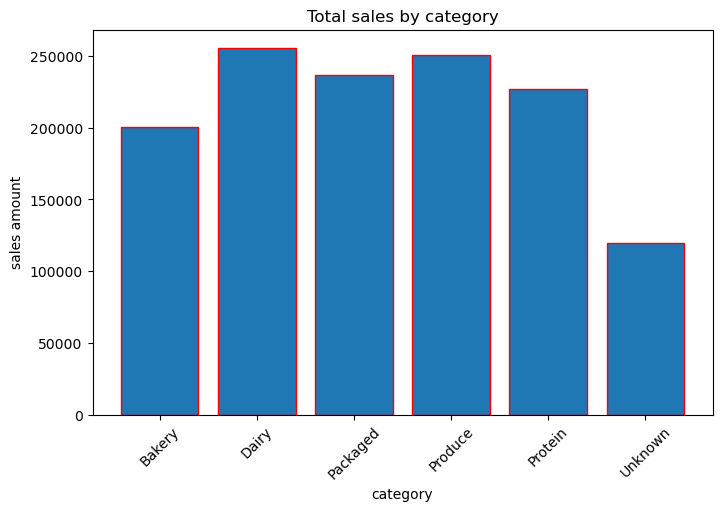

In [62]:
category_sales = df.groupby('Category')['Total_Amount'].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values, edgecolor="r")
plt.title('Total sales by category')
plt.xlabel('category')
plt.ylabel('sales amount')
plt.xticks(rotation= 45)
plt.show()

# 2. Top Cities by Sales

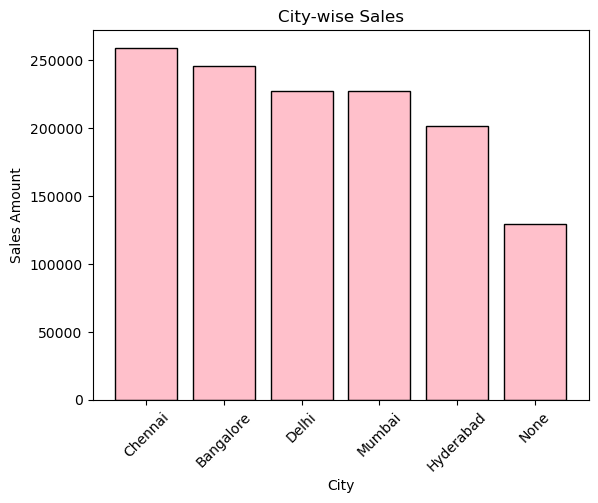

In [63]:
city_sales = df.groupby('City')['Total_Amount'].sum().sort_values(ascending= False)

plt.figure(figure=(8,5))
plt.bar(city_sales.index, city_sales.values, color= 'pink', edgecolor='black')
plt.title('City-wise Sales')
plt.xlabel('City')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

# 3. Daily Sales Trend (Line Chart)

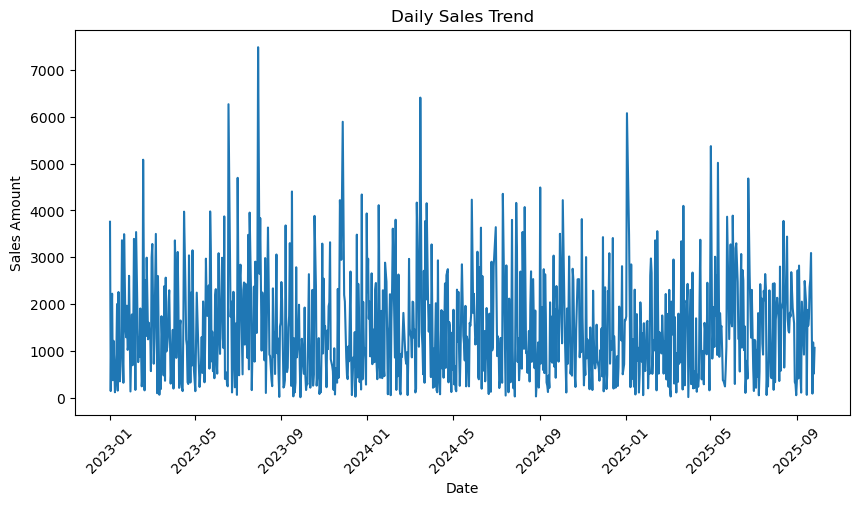

In [64]:
daily_sales = df.groupby('Order_Date')['Total_Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

# 4. Product-wise Quantity Sold

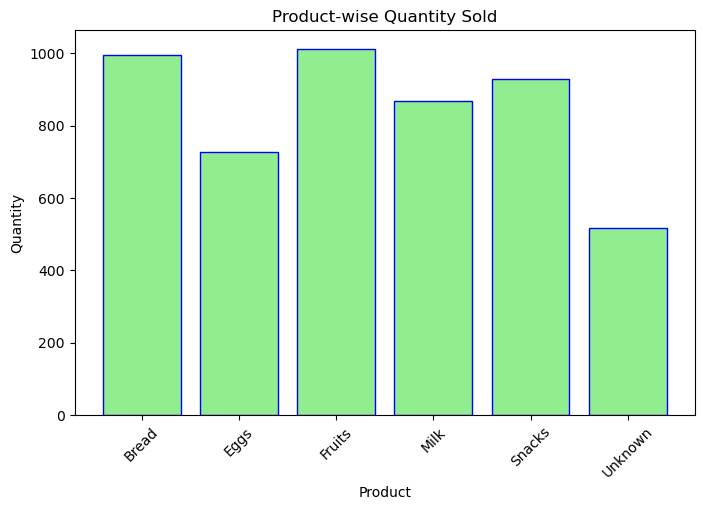

In [65]:
product_sales = df.groupby('Product')['Quantity'].sum()

plt.figure(figsize=(8,5))
plt.bar(product_sales.index, product_sales.values, color='lightgreen', edgecolor='b')
plt.title('Product-wise Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.show()

In [66]:
#After graphs,insights like:

#Highest revenue category
#Best performing city
#Most sold product
#Sales trend over time
#Seasonal/daily spikes

# 4. Histogram (Price Distribution)

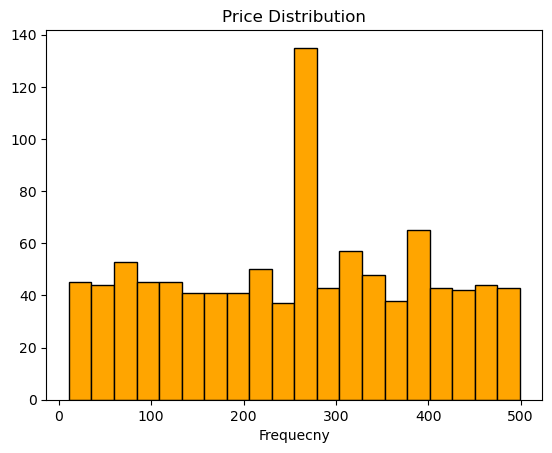

In [67]:
plt.figure(figure= (8,5))
plt.hist(df['Price'], bins = 20, color='orange', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Frequecny')
plt.show()

In [68]:
# This helps answer:
 # Are most products low-priced?
 # Are there expensive outliers?
 # Is price normally distributed?

# 5. Pie Chart (Category Sales Share)

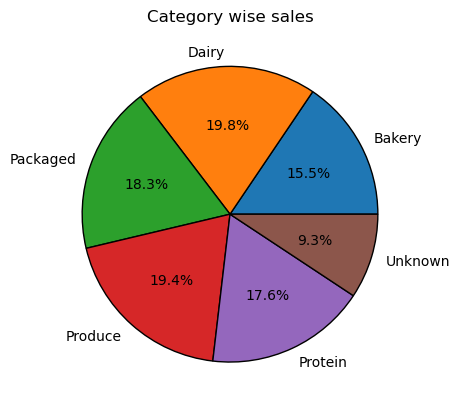

In [69]:
category_sales= df.groupby('Category')['Total_Amount'].sum()

plt.figure(figure= (7,7))
plt.pie(category_sales.values, labels= category_sales.index, autopct= '%1.1f%%',wedgeprops={"edgecolor": "black"})
plt.title("Category wise sales")
plt.show()

# 6. Scatter Plot (Price vs Quantity)

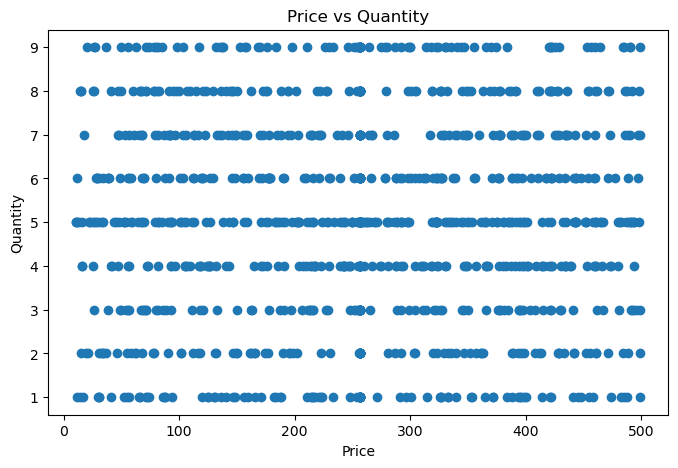

In [70]:
plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Quantity'])
plt.title('Price vs Quantity')
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.show()

# 7. Box Plot (Outlier Detection)

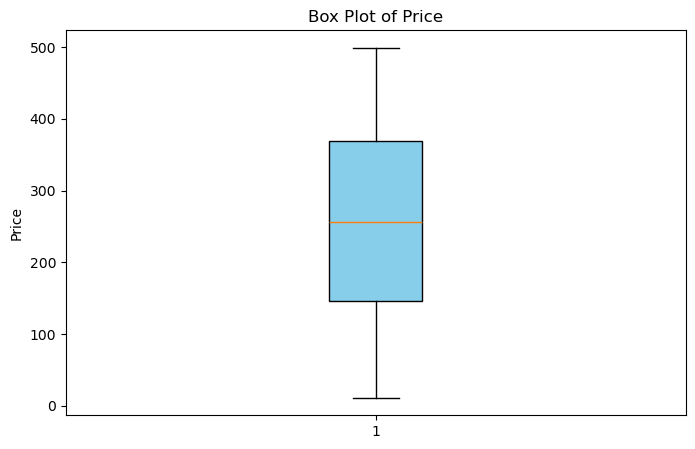

In [71]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Price'],patch_artist=True, boxprops=dict(facecolor="skyblue", color="black"))
plt.title('Box Plot of Price')
plt.ylabel('Price')
plt.show()

In [72]:
# This helps find:
# outliers
# extreme prices
# skewness